# Лабораторная работа: Интерполяция

- Студент: Платов Дмитрий Константинович
- Группа: 6
- Дата: 20.04.26

### Цель работы
Изучение методов интерполяции данных, получение базовых
навыков работы с изображениями в Python и matplotlib.

<br><br>
### Ход работы

# А) Работа с интерполяционными многочленами

### 1. Импорт необходимых библиотек

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def f(x):
    return -np.sinc(1.5 * x)

### 2. Загрузка данных из файла и отображение на графике

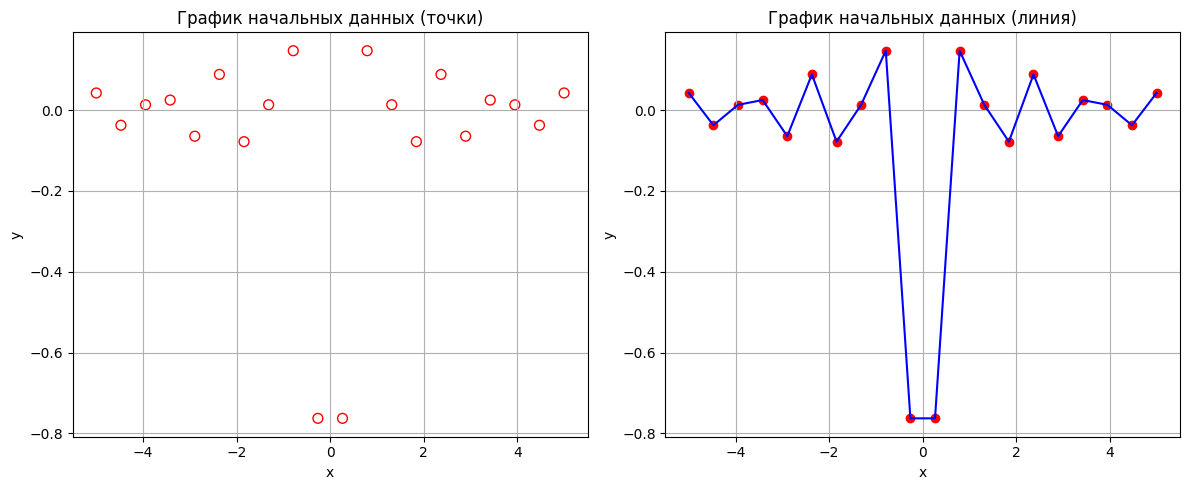

In [38]:
df = pd.read_csv('Task_Data_Interpolation.csv', sep=';')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(df['x'], df['y'], facecolors='none', edgecolors='red', s=50)
ax1.set_title('График начальных данных (точки)')
ax1.grid()
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax2.scatter(df['x'], df['y'], c='red', )
ax2.plot(df['x'], df['y'], 'b-')
ax2.set_title('График начальных данных (линия)')
ax2.grid()
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

### 3. Создание функций, реализующих процедуру интерполяции полиномом Лагранжа и полиномом Ньютона для произвольной сетки узлов.

In [39]:
def build_lagrange_polynom(n: int, x_points: [float], y_points: [float]):
    def function(x):
        res = 0
        for i in range(n):
            c_i = 1
            for j in range(n):
                if i != j:
                    c_i *= (x - x_points[j]) / (x_points[i] - x_points[j])
            res += y_points[i] * c_i
        return res

    return function


def build_newton_polynom(n: int, x_points: [float], y_points: [float]):
    cached = {}

    def build_divided_difference(left: int, right: int):
        if (left, right) in cached:
            return cached[(left, right)]
        if right - left == 1:
            return y_points[left]

        res = ((build_divided_difference(left + 1, right)
                - build_divided_difference(left, right - 1)) / (
                       x_points[right - 1] - x_points[left]))
        cached[(left, right)] = res
        return res

    def function(x):
        total = 0
        for k in range(1, n):
            res = build_divided_difference(0, k)
            for m in range(0, k - 1):
                res *= (x - x_points[m])
            total += res
        return total

    return function

### 4. Добавление новых точек. Применение созданных интерполяционных полиномов. Графики точной функции, исходных данных до интерполяции и данных после интерполяции. Выводы о точности интерполяции полиномов 

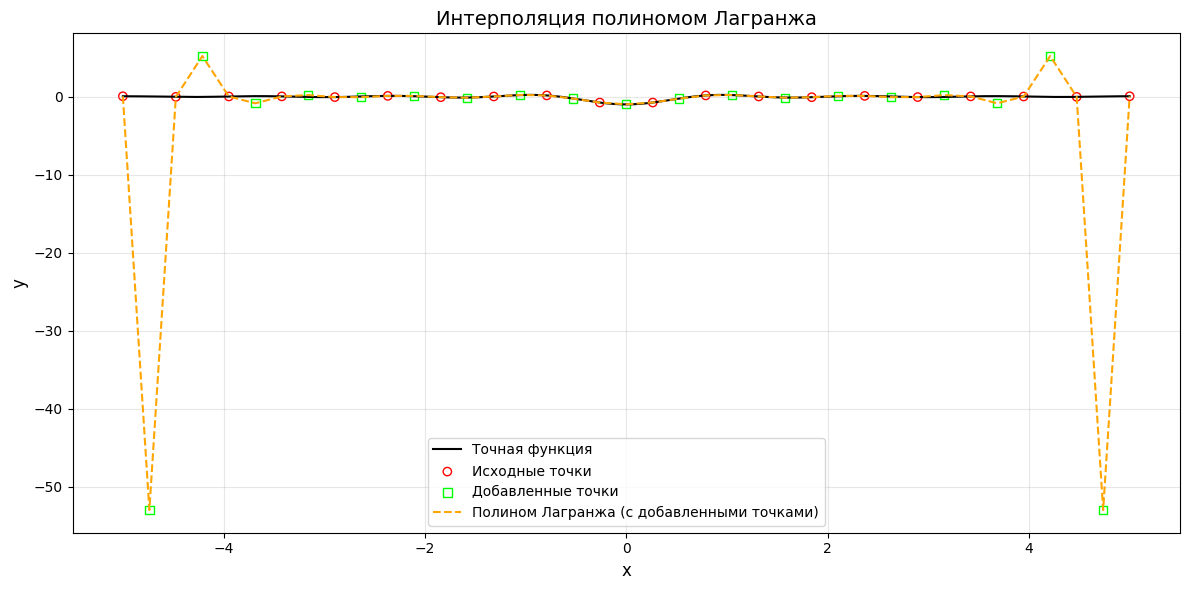

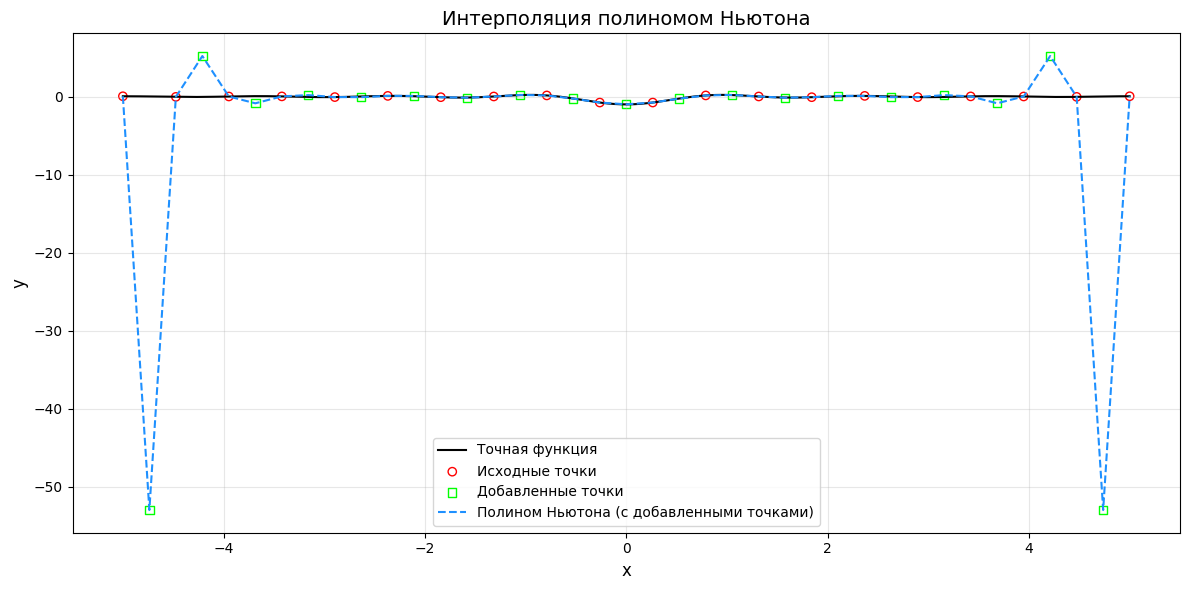

In [40]:
x = df['x'].tolist()
y = df['y'].tolist()


def plot_interpolation_comparison(x_nodes: [float], y_nodes: [float], f: callable, method: callable,
                                  method_name,
                                  n=300, color_polynom='orange'):
    x_for_func = np.linspace(x_nodes[0], x_nodes[-1], n)
    y_func = f(x_for_func)
    P = method(len(x_nodes), x_nodes, y_nodes)

    x_for_interpolation = []
    x_added = []
    for i in range(len(x_nodes) - 1):
        x_for_interpolation.append(x_nodes[i])
        x_for_interpolation.append((x_nodes[i] + x_nodes[i + 1]) / 2)
        x_added.append((x_nodes[i] + x_nodes[i + 1]) / 2)
    x_for_interpolation.append(x_nodes[-1])

    y_interpolation = np.array([P(x_cur) for x_cur in x_for_interpolation])
    y_added = np.array([P(x_cur) for x_cur in x_added])

    plt.figure(figsize=(12, 6))
    plt.plot(x_for_func, y_func, color='black', label='Точная функция')
    plt.scatter(x_nodes, y_nodes, color='red', marker='o', facecolors='none', label='Исходные точки')
    plt.scatter(x_added, y_added, color='#00FF00', marker='s', facecolors='none', label='Добавленные точки')
    plt.plot(x_for_interpolation, y_interpolation, '--', color=color_polynom,
             label=f'Полином {method_name} (с добавленными точками)')
    plt.title(f'Интерполяция полиномом {method_name}', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()


plot_interpolation_comparison(x, y, f, build_lagrange_polynom, 'Лагранжа')
plot_interpolation_comparison(x, y, f, build_newton_polynom, 'Ньютона', color_polynom='#1E90FF')

Таким образом, как и ожидалось, полиномы идентичны. Малое различие может присутствовать, но прежде всего оно обусловлено ошибками округления, которых невозможно избежать в современной технике. В середине интервала [-5;5] графики полиномов(формально полинома) совпадают с графиком исходной функции, но на границах интервала погрешность значительна 

### 5. Создание нового набора данных, состоящего из 20 точек, абсциссами которых являются корни полинома Чебышева. 

In [41]:
def calc_сhebyshev_roots(left: float, right: float, k: int):
    x = []
    for i in range(1, k + 1):
        x.append((left + right) / 2 + (right - left) / 2 * np.cos(((2 * i - 1) / (2 * k)) * np.pi))
    return np.array(x)


cheb_x = calc_сhebyshev_roots(-5, 5, 20)
cheb_y = f(cheb_x)

### 6. Построение полиномов по новым данным. Интерполяция значений в добавленных точках. Графики полученных полиномов.

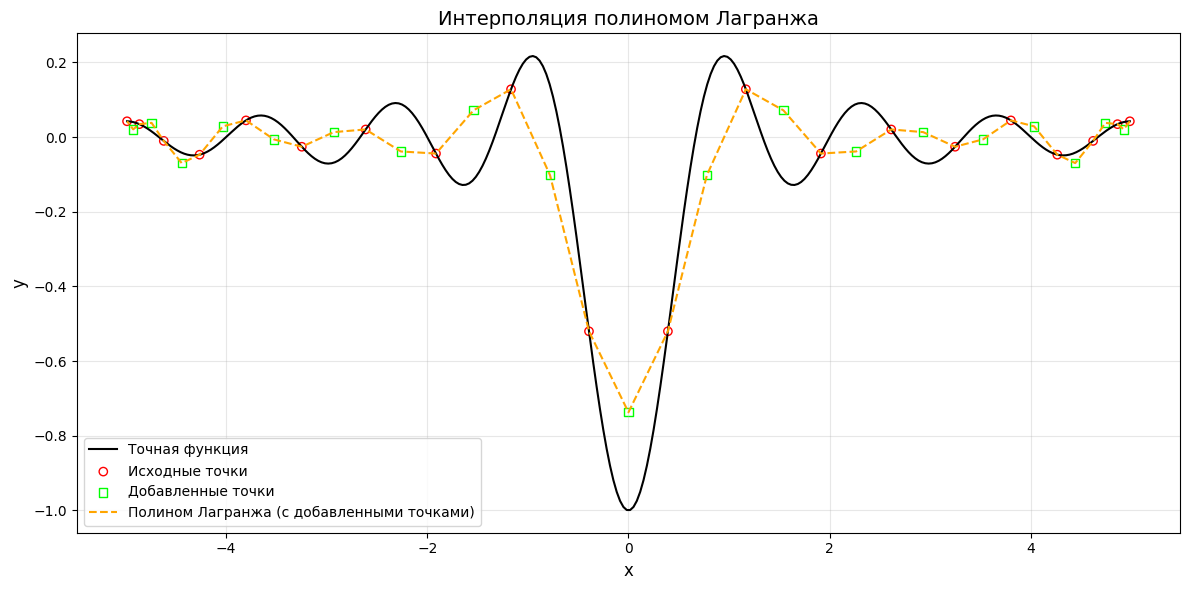

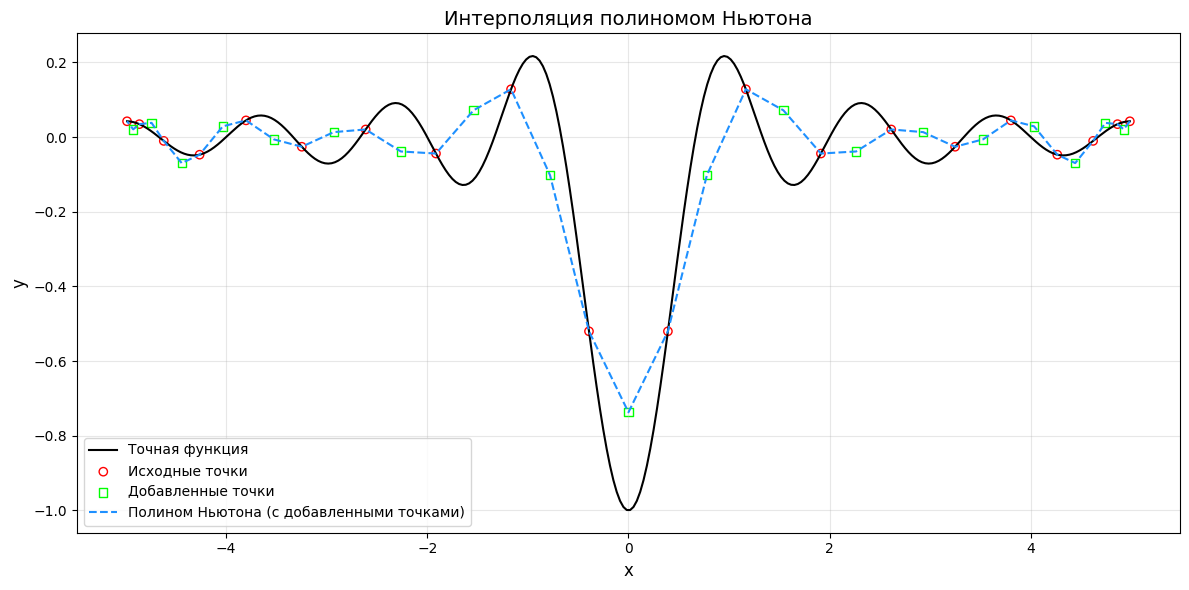

In [42]:
plot_interpolation_comparison(cheb_x, cheb_y, f, method=build_lagrange_polynom, method_name='Лагранжа')

plot_interpolation_comparison(cheb_x, cheb_y, f, method=build_newton_polynom, method_name='Ньютона',
                              color_polynom='#1E90FF')

### 7. Итоговые выводы
- Методы Лагранжа и Ньютона строят один и тот же полином, однако метод Ньютона удобнее в практическом применении. Степень многочлена можно повышать добавлением узлов, что имеет большое практическое удобство. При добавлении нового узла все вычисленные ранее слагаемые остаются без изменений, а к сумме добавляется только одно новое слагаемое.
- При использовании произвольной (в частности, равномерной) сетки на границах интервала возникают значительные осцилляции интерполяционного полинома, что приводит к большим погрешностям относительно истинной функции. Узлы Чебышёва за счёт сгущения на краях интервала минимизируют этот эффект и позволяют существенно повысить точность интерполяции на границах при том же количестве узлов.
- Применение равномерной сетки для большого числа узлов приводит к недопустимой погрешности на границах интервала. Рекомендуется использовать узлы Чебышёва или, возможно, переходить к кусочной интерполяции.

# Б) Работа с изображениями. Кусочная интерполяция

### 1. Загрузка исходного изображения 

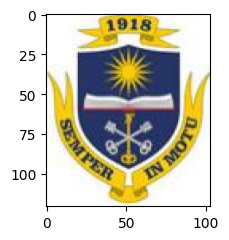

Тип данных: uint8
Форма массива: (121, 103, 3)
Общее количество элементов: 37389
Общее количество пикселей: 12463
Размер в байтах: 37389


In [43]:
_ = plt.figure(figsize=(2.5, 2.5))
img = plt.imread('task_vsu_gerb.jpeg')
plt.imshow(img)
plt.show()

print(f"Тип данных: {img.dtype}")
print(f"Форма массива: {img.shape}")
print(f"Общее количество элементов: {img.size}")
print(f"Общее количество пикселей: {int(img.size / 3)}")
print(f"Размер в байтах: {img.nbytes}")

Загруженное изображение хранится в памяти как трёхмерный массив NumPy типа uint8. Форма массива - (высота, ширина, 3), где третье измерение соответствует цветовым каналам RGB. Общее количество элементов массива равно высота * ширина * 3, количество пикселей - высота * ширина, а размер в байтах совпадает с количеством элементов, так как каждый элемент занимает 1 байт.



### 2. Реализация функций, позволяющих увеличивать размер изображения (функции кусочной интерполяции)

In [44]:
import os


def increase_by_interpolation_over_nearest_neighbors(image: np.ndarray, scale_factor: int):
    h, w, ch = image.shape
    new_h = h * scale_factor
    new_w = w * scale_factor

    new_image = np.zeros((new_h, new_w, ch), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            nearest_pixel = image[min(i // scale_factor, h - 1), min(j // scale_factor, w - 1)]
            new_image[i, j] = nearest_pixel
    return new_image


def increase_by_vertical_linear_interpolation(image: np.ndarray, scale_factor: int):
    h, w, ch = image.shape
    new_h = h * scale_factor
    new_w = w

    image_float = image.astype(np.float64)
    new_image = np.zeros((new_h, new_w, ch), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            h_index_start = int(min(np.floor(i / scale_factor), h - 2))
            h_index_end = h_index_start + 1
            pixel_start = image_float[h_index_start, j]
            pixel_end = image_float[h_index_end, j]
            t_h = (i / scale_factor) - np.floor(i / scale_factor)
            pixel_res = np.clip(
                np.round(pixel_start + (pixel_end - pixel_start) * t_h),
                0, 255
            ).astype(image.dtype)
            new_image[i, j] = pixel_res
    return new_image


def increase_by_horizontal_linear_interpolation(image: np.ndarray, scale_factor: int):
    h, w, ch = image.shape
    new_h = h
    new_w = w * scale_factor

    image_float = image.astype(np.float64)
    new_image = np.zeros((new_h, new_w, ch), dtype=image.dtype)

    for i in range(new_h):
        for j in range(new_w):
            w_index_start = int(min(np.floor(j / scale_factor), w - 2))
            w_index_end = w_index_start + 1
            pixel_start = image_float[i, w_index_start]
            pixel_end = image_float[i, w_index_end]
            t_w = (j / scale_factor) - np.floor(j / scale_factor)
            pixel_res = np.clip(
                np.round(pixel_start + (pixel_end - pixel_start) * t_w),
                0, 255
            ).astype(image.dtype)
            new_image[i, j] = pixel_res

    return new_image


def increase_by_bilinear_interpolation(image: np.ndarray, scale_factor: int):
    temp_image = increase_by_horizontal_linear_interpolation(image, scale_factor)
    return increase_by_vertical_linear_interpolation(temp_image, scale_factor)


def increase_by_bicubic_interpolation_horizontal(image: np.ndarray, scale_factor: int):
    h, w, ch = image.shape
    new_h = h
    new_w = w * scale_factor

    image_float = image.astype(np.float64)
    new_image = np.zeros((new_h, new_w, 3), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            x_raw = j / scale_factor
            x = int(np.floor(x_raw))
            dx = x_raw - x
            p_prev2 = image_float[i, max(0, min(w - 1, x - 1))]
            p_prev1 = image_float[i, max(0, min(w - 1, x))]
            p_next1 = image_float[i, max(0, min(w - 1, x + 1))]
            p_next2 = image_float[i, max(0, min(w - 1, x + 2))]

            # это берется из решения системы для polynom=a*t^3 + b*t^2 + c*t + d
            # при этом есть 4 условия dx=0 -> polynom=начальная_точка, dx=1 -> polynom=конечная_точкя
            t = dx
            t2 = t * t
            t3 = t2 * t
            w0 = 0.5 * (-t3 + 2 * t2 - t)
            w1 = 0.5 * (3 * t3 - 5 * t2 + 2)
            w2 = 0.5 * (-3 * t3 + 4 * t2 + t)
            w3 = 0.5 * (t3 - t2)
            pixel_res = p_prev2 * w0 + p_prev1 * w1 + p_next1 * w2 + p_next2 * w3
            pixel_res = np.clip(pixel_res, 0, 255).astype(image.dtype)
            new_image[i, j] = pixel_res
    return new_image


def increase_by_bicubic_interpolation_vertical(image: np.ndarray, scale_factor: int):
    h, w, ch = image.shape
    new_h = h * scale_factor
    new_w = w

    image_float = image.astype(np.float64)
    new_image = np.zeros((new_h, new_w, 3), dtype=image.dtype)
    for i in range(new_h):
        for j in range(new_w):
            y_raw = i / scale_factor
            y = int(np.floor(y_raw))
            dy = y_raw - y
            p_prev2 = image_float[max(0, min(h - 1, y - 1)), j]
            p_prev1 = image_float[max(0, min(h - 1, y)), j]
            p_next1 = image_float[max(0, min(h - 1, y + 1)), j]
            p_next2 = image_float[max(0, min(h - 1, y + 2)), j]

            # это берется из решения системы для polynom=a*t^3 + b*t^2 + c*t + d
            # при этом есть 4 условия dx=0 -> polynom=начальная_точка, dx=1 -> polynom=конечная_точкя
            t = dy
            t2 = t * t
            t3 = t2 * t
            w0 = 0.5 * (-t3 + 2 * t2 - t)
            w1 = 0.5 * (3 * t3 - 5 * t2 + 2)
            w2 = 0.5 * (-3 * t3 + 4 * t2 + t)
            w3 = 0.5 * (t3 - t2)
            pixel_res = p_prev2 * w0 + p_prev1 * w1 + p_next1 * w2 + p_next2 * w3
            pixel_res = np.clip(pixel_res, 0, 255).astype(image.dtype)
            new_image[i, j] = pixel_res
    return new_image


def increase_by_bicubic_interpolation(image: np.ndarray, scale_factor: int):
    temp_image = increase_by_bicubic_interpolation_horizontal(image, scale_factor)
    return increase_by_bicubic_interpolation_vertical(temp_image, scale_factor)

### 3. Использование функций. Сравнение результатов

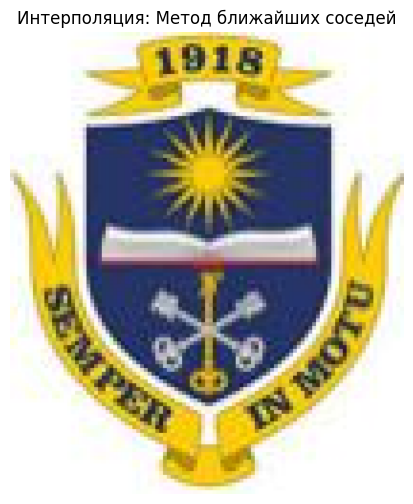

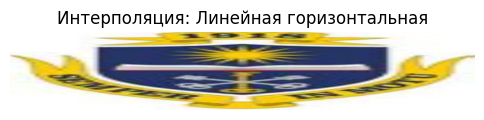

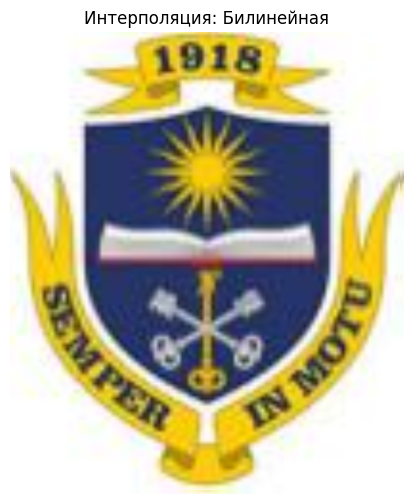

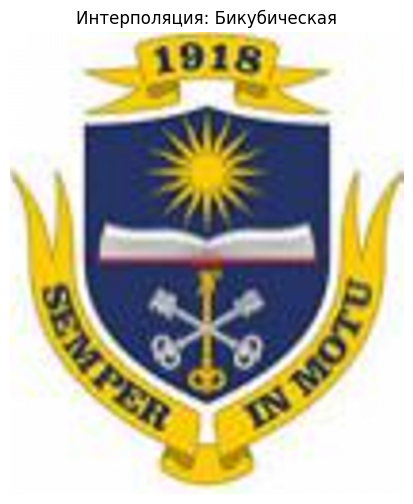

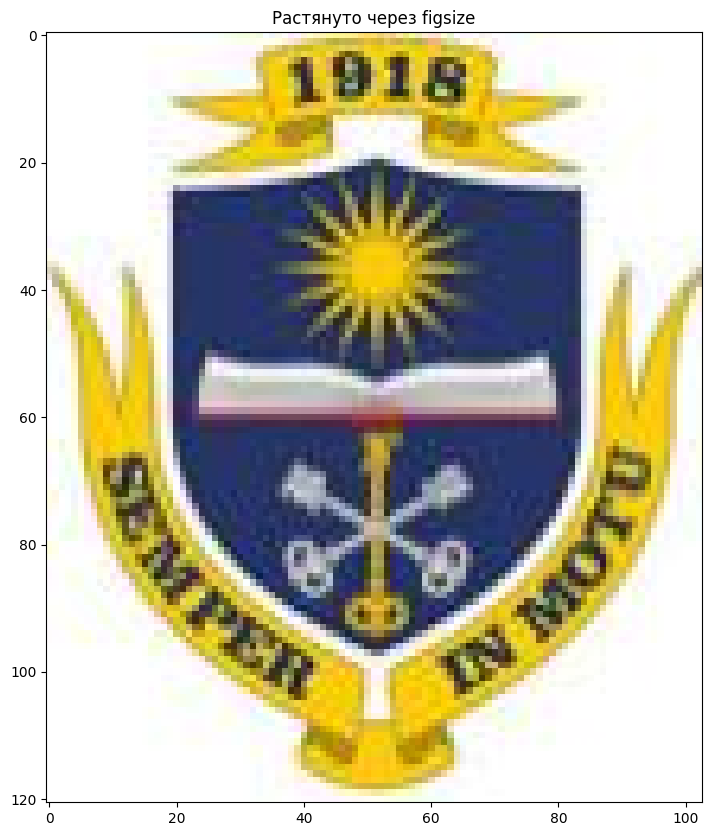

In [45]:
def process_and_save(image, scale_factor, folder_name="results"):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)

    methods = [
            ("Метод ближайших соседей", increase_by_interpolation_over_nearest_neighbors),
        ("Линейная горизонтальная", increase_by_horizontal_linear_interpolation),
        ("Билинейная", increase_by_bilinear_interpolation),
        ("Бикубическая", increase_by_bicubic_interpolation)
    ]

    for name, func in methods:
        res = func(image, scale_factor)

        plt.figure(figsize=(6, 6))
        plt.title(f"Интерполяция: {name}")
        plt.imshow(res)
        plt.axis('off')
        plt.show()

        file_path = os.path.join(folder_name, f"result_{name}.png")
        plt.imsave(file_path, res)


process_and_save(img, 7)
plt.figure(figsize=(10, 10))
plt.title("Растянуто через figsize")
plt.imshow(img)
plt.show()

### 4. Выводы:
- Метод ближайшего соседа сохраняет резкость, но дает сильную «ступенчатость». Билинейная интерполяция делает переходы мягкими, но слегка замыливает детали. Бикубический метод - самый качественный: за счет использования сложных кривых он лучше всего сохраняет четкость границ и естественность градиентов, минимизируя визуальные потери при масштабировании.
- Метод ближайшего соседа - самый быстрый, так как требует только копирования значений. Билинейная интерполяция работает медленнее из-за расчетов весов, а бикубическая - самая ресурсозатратная, так как анализирует в 4 раза больше соседних пикселей для каждой точки.
- Figsize - это просто изменение масштаба окна, а не создание новой картинки. Оно не добавляет в массив ни одного нового пикселя, а лишь растягивает старые данные на весь экран. Формально используется интерполяция 0 степени.


